## Variational Bayes for Normal Model

This notebook demonstrates how to apply Mean-Field Variational Bayes (MFVB) and Fixed Form Variational Bayes (FFVB). The implementation follows the practical tutorial by Tran, Nguyen and Dao (2021), whose original MATLAB code has been translated to Python.

## Example 1: MFVB with normal proior 

### Step 1: Define MFVB alogrithm based on normal prior assumtion 

In [1]:
"""
Mean-Field Variational Bayes (MFVB) for the Normal model
Reference: "A practical tutorial on Variational Bayes" by Minh-Ngoc Tran

Python translation of the original MATLAB script.
Structure:
    1. Helper functions (Gibbs sampler + MFVB optimiser)
    2. Synthetic data
    3. Execution + visualisation (MCMC vs VB posterior densities)
"""
import time
import numpy as np
from scipy.stats import gaussian_kde, norm, invgamma
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------------------
def gibbs_normal_model(y, alpha0, beta0, mu0, sigma20,
                        Nburn=10000, Niter=20000, seed=2020):
    """
    Gibbs sampler for the normal model:
        y_i | mu, sigma2 ~ N(mu, sigma2)
        mu               ~ N(mu0, sigma20)
        sigma2           ~ InvGamma(alpha0, beta0)

    Returns
    -------
    mu_mcmc, sigma2_mcmc : ndarray
        Post burn-in MCMC draws.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    n = len(y)
    y_bar = y.mean()

    N = Nburn + Niter
    mu_mcmc = np.zeros(N)
    sigma2_mcmc = np.zeros(N)

    # initial values sample mean and sample variance
    mu_mcmc[0] = y_bar
    sigma2_mcmc[0] = y.var(ddof=1)

    for i in range(N - 1):
        # full conditional for mu
        scale = 1.0 / (1.0 / sigma20 + n / sigma2_mcmc[i])
        location = n * y_bar / sigma2_mcmc[i] * scale
        mu_mcmc[i + 1] = rng.normal(location, np.sqrt(scale))

        # full conditional for sigma2 (via precision ~ Gamma)
        shape = n / 2 + alpha0
        rate = beta0 + np.sum((y - mu_mcmc[i + 1]) ** 2) / 2
        # numpy's gamma(shape, scale) uses scale = 1/rate
        # Random Gamma: gamrnd(shape, 1/rate)
        precision = rng.gamma(shape, 1.0 / rate)
        sigma2_mcmc[i + 1] = 1.0 / precision

    return mu_mcmc[Nburn:], sigma2_mcmc[Nburn:]


def mfvb_normal_model(y, alpha0, beta0, mu0, sigma20,
                       eps=1e-4, max_iter=10000):
    """
    Mean-field variational Bayes for the normal model.

    Variational family:
        q(mu)     = N(muq, sigma2q)
        q(sigma2) = InvGamma(alphaq, betaq)

    Returns
    -------
    muq, sigma2q, alphaq, betaq : float
        Optimal variational parameters.
    n_iter : int
        Number of CAVI iterations performed.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    sum_y2 = np.sum(y ** 2)
    y_bar = y.mean()

    # initial values
    muq = y_bar
    sigma2q = 1.0
    alphaq = alpha0 + n / 2  # alpha_q never changes, so update it once

    params_new = np.array([alpha0, beta0, mu0, sigma20], dtype=float)
    n_iter = 0
    converged = False

    while not converged and n_iter < max_iter:
        params_old = params_new

        betaq = beta0 + sum_y2 / 2 - n * y_bar * muq + n * (muq ** 2 + sigma2q) / 2
        sigma2q = 1.0 / (1.0 / sigma20 + n * alphaq / betaq)
        muq = (mu0 / sigma20 + n * y_bar * alphaq / betaq) * sigma2q

        params_new = np.array([alphaq, betaq, muq, sigma2q])
        n_iter += 1
        if np.linalg.norm(params_new - params_old) < eps:
            converged = True

    return muq, sigma2q, alphaq, betaq, n_iter



### Step 2: Exectuve MFVB using simulated data and visaulize the results 

CPU time MCMC: 0.1862 s
CPU time VB:   0.0004 s  (7 CAVI iterations)
VB estimates -> muq=9.4018, sigma2q=0.3074, alphaq=6.0000, betaq=19.0319


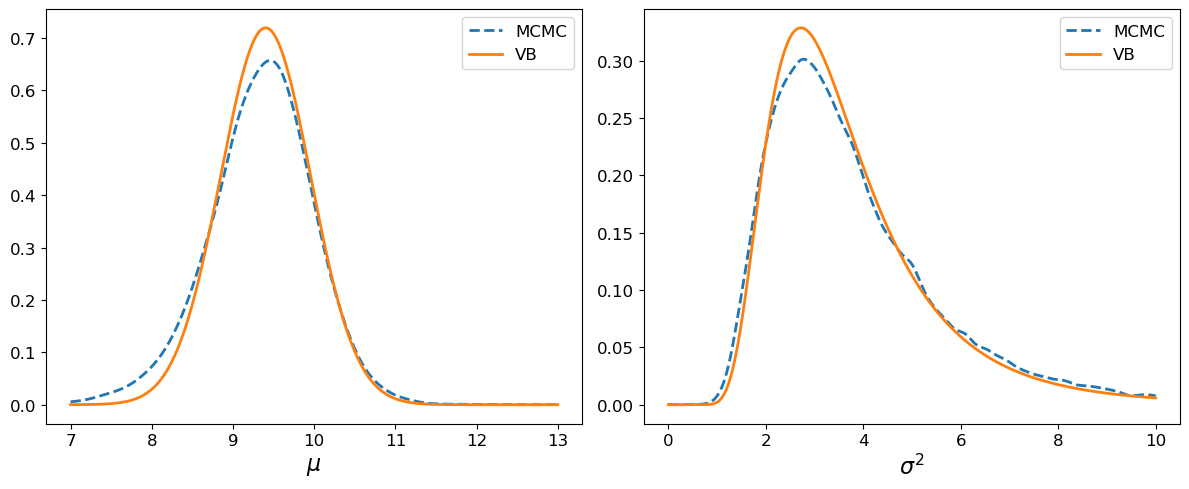

In [2]:

# ---------------------------------------------------------------------
# 2. Synthetic data
# ---------------------------------------------------------------------
y = np.array([11, 12, 8, 10, 9, 8, 9, 10, 13, 7], dtype=float)
n = len(y)

# hyperparameters
alpha0, beta0, mu0, sigma20 = 1.0, 1.0, 0.0, 10.0


# ---------------------------------------------------------------------
# 3. Execution + visualisation
# ---------------------------------------------------------------------

# --- Gibbs sampling (MCMC) ---
t0 = time.time()
mu_mcmc, sigma2_mcmc = gibbs_normal_model(y, alpha0, beta0, mu0, sigma20, 
                                          Nburn=10000, Niter=20000, seed=2020)
cpu_mcmc = time.time() - t0
print(f"CPU time MCMC: {cpu_mcmc:.4f} s")

# --- MFVB ---
t0 = time.time()
muq, sigma2q, alphaq, betaq, n_iter = mfvb_normal_model(y, alpha0, beta0, mu0, sigma20,
                                                        eps=1e-4)
cpu_vb = time.time() - t0
print(f"CPU time VB:   {cpu_vb:.4f} s  ({n_iter} CAVI iterations)")
print(f"VB estimates -> muq={muq:.4f}, sigma2q={sigma2q:.4f}, "
      f"alphaq={alphaq:.4f}, betaq={betaq:.4f}")

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: mu
x_mu = np.arange(7, 13, 0.0001)
kde_mu = gaussian_kde(mu_mcmc, bw_method=0.14 / mu_mcmc.std(ddof=1))
yy_mcmc_mu = kde_mu(x_mu)
yy_vb_mu = norm.pdf(x_mu, muq, np.sqrt(sigma2q))

axes[0].plot(x_mu, yy_mcmc_mu, '--', linewidth=2, label='MCMC')
axes[0].plot(x_mu, yy_vb_mu, '-', linewidth=2, label='VB')
axes[0].set_xlabel(r'$\mu$', fontsize=16)
axes[0].legend(fontsize=12)
axes[0].tick_params(labelsize=12)

# Panel 2: sigma2
x_s2 = np.arange(0, 10, 0.0001)[1:]
kde_s2 = gaussian_kde(sigma2_mcmc, bw_method=0.14 / sigma2_mcmc.std(ddof=1))
yy_mcmc_s2 = kde_s2(x_s2)
yy_vb_s2 = invgamma.pdf(x_s2, a=alphaq, scale=betaq)

axes[1].plot(x_s2, yy_mcmc_s2, '--', linewidth=2, label='MCMC')
axes[1].plot(x_s2, yy_vb_s2, '-', linewidth=2, label='VB')
axes[1].set_xlabel(r'$\sigma^2$', fontsize=16)
axes[1].legend(fontsize=12)
axes[1].tick_params(labelsize=12)

fig.tight_layout()
plt.show()

As shown in the figures, the estimated densities of $\mu$ and $\sigma^2$ based on the Gibbs sampler (MCMC) and Variational Bayes (MFVB) are quite similar. The VB approximation closely matches the MCMC posterior distributions for both parameters, with only minor discrepancies in the tails. This demonstrates that the mean-field variational approximation provides a computationally efficient alternative to MCMC for this normal model, achieving comparable accuracy while being significantly faster. 

## Example 2:  FFVB with control variate and adaptive learning

### Step 1: Define FFVB algorithm 

In [3]:
"""
Fixed-Form Variational Bayes (FFVB) with Control Variates and Adaptive Learning
for the normal model example (Example 3.1 from Tran, Nguyen & Dao, 2021)

This implementation includes:
- FFVB with ADAM and ADADELTA optimizers
- Control variates for variance reduction
- Gibbs sampling for comparison
- Visualization of posterior densities
"""

import time
import numpy as np
from scipy.stats import norm, gamma, invgamma, gaussian_kde
from scipy.special import psi, gammaln
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


# ---------------------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------------------

def h_lambda_fun(y, mu, sigma2, alpha_hp, beta_hp, mu_hp, sigma2_hp, 
                 mu_mu, sigma2_mu, alpha_sigma2, beta_sigma2):
    """
    Compute the function h(lambda) = log p(y, theta) - log q(theta; lambda)
    for the normal model.
    """
    n = len(y)
    sum_y2 = np.sum(y**2)
    y_bar = np.mean(y)
    
    # log p(y | theta)
    log_lik = -n/2 * np.log(2*np.pi) - n/2 * np.log(sigma2) - np.sum((y - mu)**2) / (2*sigma2)
    
    # log p(mu)
    log_p_mu = -0.5*np.log(2*np.pi*sigma2_hp) - (mu - mu_hp)**2 / (2*sigma2_hp)
    
    # log p(sigma2)
    log_p_sigma2 = alpha_hp*np.log(beta_hp) - gammaln(alpha_hp) - (alpha_hp+1)*np.log(sigma2) - beta_hp/sigma2
    
    # log q(mu)
    log_q_mu = -0.5*np.log(2*np.pi*sigma2_mu) - (mu - mu_mu)**2 / (2*sigma2_mu)
    
    # log q(sigma2)
    log_q_sigma2 = alpha_sigma2*np.log(beta_sigma2) - gammaln(alpha_sigma2) - (alpha_sigma2+1)*np.log(sigma2) - beta_sigma2/sigma2
    
    return log_lik + log_p_mu + log_p_sigma2 - log_q_mu - log_q_sigma2


def gibbs_normal_model(y, alpha0, beta0, mu0, sigma20, Nburn=10000, Niter=20000, seed=2020):
    """
    Gibbs sampler for the normal model.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    n = len(y)
    y_bar = y.mean()
    
    N = Nburn + Niter
    mu_mcmc = np.zeros(N)
    sigma2_mcmc = np.zeros(N)
    
    mu_mcmc[0] = y_bar
    sigma2_mcmc[0] = y.var(ddof=1)
    
    for i in range(N - 1):
        scale = 1.0 / (1.0 / sigma20 + n / sigma2_mcmc[i])
        location = n * y_bar / sigma2_mcmc[i] * scale
        mu_mcmc[i + 1] = rng.normal(location, np.sqrt(scale))
        
        shape = n / 2 + alpha0
        rate = beta0 + np.sum((y - mu_mcmc[i + 1]) ** 2) / 2
        precision = rng.gamma(shape, 1.0 / rate)
        sigma2_mcmc[i + 1] = 1.0 / precision
    
    return mu_mcmc[Nburn:], sigma2_mcmc[Nburn:]


def ffvb_normal_model(y, alpha_hp, beta_hp, mu_hp, sigma2_hp, 
                      S=1000, max_iter=2000, patience_max=20, t_w=50,
                      optimizer='ADAM', eps0=0.1, seed=1000):
    """
    Fixed-Form Variational Bayes with control variates and adaptive learning.
    
    Parameters
    ----------
    y : array-like
        Data
    alpha_hp, beta_hp, mu_hp, sigma2_hp : float
        Hyperparameters
    S : int
        Number of Monte Carlo samples
    max_iter : int
        Maximum number of iterations
    patience_max : int
        Early stopping patience
    t_w : int
        Window size for moving average
    optimizer : str
        'ADAM' or 'ADADELTA'
    eps0 : float
        Initial learning rate
    seed : int
        Random seed
    
    Returns
    -------
    lambda_opt : array
        Optimal variational parameters [mu_mu, sigma2_mu, alpha_sigma2, beta_sigma2]
    LB_bar : array
        Moving average of lower bound
    """
    np.random.seed(seed)
    y = np.asarray(y, dtype=float)
    n = len(y)
    d = 4  # number of parameters
    
    # ADAM parameters
    beta1_adap_weight = 0.9
    beta2_adap_weight = 0.9
    
    # ADADELTA parameters
    w_adadelta = 0.95
    eps_adadelta = 1e-7
    
    tau_threshold = max_iter / 2
    
    # Initial lambda
    lambda_ = np.array([np.mean(y), 1.5, 2.0, 3.0])
    lambda_best = lambda_.copy()
    
    # Initialize optimizers
    if optimizer == 'ADADELTA':
        delta2_bar = np.zeros(d)
        g2_bar = np.zeros(d)
    elif optimizer == 'ADAM':
        g_bar_adaptive = np.zeros(d)
        v_bar_adaptive = np.zeros(d)
    
    # Main loop
    iter_ = 1
    stop = False
    LB = []
    LB_bar = []
    patience = 0
    
    while not stop:
        mu_mu, sigma2_mu, alpha_sigma2, beta_sigma2 = lambda_
        
        # Monte Carlo samples
        h_lambda_samples = np.zeros(S)
        grad_log_q_lambda = np.zeros((S, d))
        grad_log_q_times_h = np.zeros((S, d))
        grad_log_q_times_h_cv = np.zeros((S, d))
        
        # Generate samples (vectorized for efficiency)
        mu_samples = np.random.normal(mu_mu, np.sqrt(sigma2_mu), S)
        sigma2_samples = 1.0 / np.random.gamma(alpha_sigma2, 1.0/beta_sigma2, S)
        
        for s in range(S):
            mu = mu_samples[s]
            sigma2 = sigma2_samples[s]
            
            grad_log_q_lambda[s, :] = [
                (mu - mu_mu) / sigma2_mu,
                -1/(2*sigma2_mu) + (mu - mu_mu)**2 / (2*sigma2_mu**2),
                np.log(beta_sigma2) - psi(alpha_sigma2) - np.log(sigma2),
                alpha_sigma2/beta_sigma2 - 1/sigma2
            ]
            
            h_lambda_samples[s] = h_lambda_fun(y, mu, sigma2, alpha_hp, beta_hp, 
                                               mu_hp, sigma2_hp, mu_mu, sigma2_mu, 
                                               alpha_sigma2, beta_sigma2)
            
            grad_log_q_times_h[s, :] = grad_log_q_lambda[s, :] * h_lambda_samples[s]
        
        # Compute control variates
        cv = np.zeros(d)
        for i in range(d):
            cov_matrix = np.cov(grad_log_q_times_h[:, i], grad_log_q_lambda[:, i])
            cv[i] = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] != 0 else 0
        
        # Apply control variates
        for s in range(S):
            grad_log_q_times_h_cv[s, :] = grad_log_q_lambda[s, :] * (h_lambda_samples[s] - cv)
        
        grad_LB = np.mean(grad_log_q_times_h_cv, axis=0)
        
        # Update parameters
        if optimizer == 'ADADELTA':
            g2_bar = w_adadelta * g2_bar + (1 - w_adadelta) * grad_LB**2
            rho = np.sqrt(delta2_bar + eps_adadelta) / np.sqrt(g2_bar + eps_adadelta)
            delta_lambda = rho * grad_LB
            delta2_bar = w_adadelta * delta2_bar + (1 - w_adadelta) * delta_lambda**2
            lambda_ = lambda_ + delta_lambda
            
        elif optimizer == 'ADAM':
            g_bar_adaptive = beta1_adap_weight * g_bar_adaptive + (1 - beta1_adap_weight) * grad_LB
            v_bar_adaptive = beta2_adap_weight * v_bar_adaptive + (1 - beta2_adap_weight) * grad_LB**2
            
            if iter_ >= tau_threshold:
                stepsize = eps0 * tau_threshold / iter_
            else:
                stepsize = eps0
            
            lambda_ = lambda_ + stepsize * g_bar_adaptive / (np.sqrt(v_bar_adaptive) + 1e-8)
        
        # Store lower bound
        LB.append(np.mean(h_lambda_samples))
        
        # Moving average
        if iter_ >= t_w:
            LB_bar.append(np.mean(LB[-t_w:]))
            
            # Check for improvement
            if iter_ == t_w:
                lambda_best = lambda_.copy()
            elif LB_bar[-1] >= max(LB_bar):
                lambda_best = lambda_.copy()
                patience = 0
            else:
                patience += 1
        
        # Stopping criteria
        if patience > patience_max or iter_ > max_iter:
            stop = True
        
        iter_ += 1
    
    return lambda_best, np.array(LB_bar)


### Step 2: Exectuve FFVB with simulated data and visualize it 

FFVB with Control Variates and Adaptive Learning

CPU time FFVB: 5.7679 s
Optimal parameters:
  mu_mu = 9.3834
  sigma2_mu = 0.3080
  alpha_sigma2 = 5.8963
  beta_sigma2 = 18.7751

Running Gibbs sampling...
CPU time MCMC: 0.1589 s


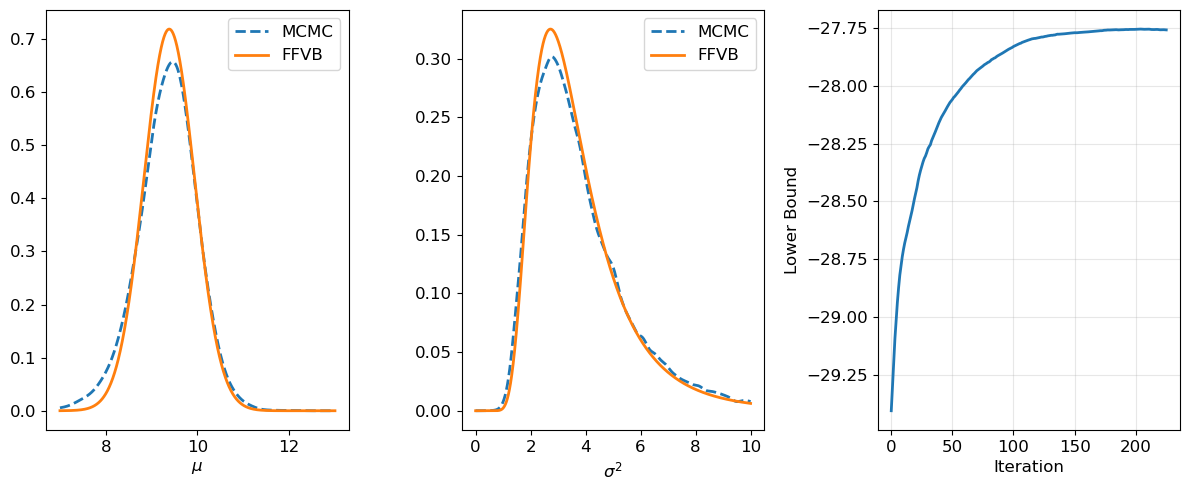

In [4]:
# ---------------------------------------------------------------------
# 2. Data and hyperparameters
# ---------------------------------------------------------------------
y = np.array([11, 12, 8, 10, 9, 8, 9, 10, 13, 7])
n = len(y)

# Hyperparameters
alpha_hp, beta_hp = 1.0, 1.0
mu_hp, sigma2_hp = 0.0, 10.0

# ---------------------------------------------------------------------
# 3. Execution and visualization
# ---------------------------------------------------------------------

print("=" * 60)
print("FFVB with Control Variates and Adaptive Learning")
print("=" * 60)

# Run FFVB
t0 = time.time()
lambda_opt, LB_bar = ffvb_normal_model(
    y, alpha_hp, beta_hp, mu_hp, sigma2_hp,
    S=1000, max_iter=2000, patience_max=20, t_w=50,
    optimizer='ADAM', eps0=0.1, seed=1000
)
cpu_ffvb = time.time() - t0

mu_mu, sigma2_mu, alpha_sigma2, beta_sigma2 = lambda_opt

print(f"\nCPU time FFVB: {cpu_ffvb:.4f} s")
print(f"Optimal parameters:")
print(f"  mu_mu = {mu_mu:.4f}")
print(f"  sigma2_mu = {sigma2_mu:.4f}")
print(f"  alpha_sigma2 = {alpha_sigma2:.4f}")
print(f"  beta_sigma2 = {beta_sigma2:.4f}")

# Run Gibbs sampling
print("\nRunning Gibbs sampling...")
t0 = time.time()
mu_mcmc, sigma2_mcmc = gibbs_normal_model(
    y, alpha_hp, beta_hp, mu_hp, sigma2_hp,
    Nburn=10000, Niter=20000, seed=2020
)
cpu_mcmc = time.time() - t0
print(f"CPU time MCMC: {cpu_mcmc:.4f} s")


# Display the results 
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fontsize = 12

# Panel 1: mu
x_mu = np.arange(7, 13, 0.001)
kde_mu = gaussian_kde(mu_mcmc, bw_method=0.14 / mu_mcmc.std(ddof=1))
yy_mcmc_mu = kde_mu(x_mu)
yy_vb_mu = norm.pdf(x_mu, mu_mu, np.sqrt(sigma2_mu))

axes[0].plot(x_mu, yy_mcmc_mu, '--', linewidth=2, label='MCMC')
axes[0].plot(x_mu, yy_vb_mu, '-', linewidth=2, label='FFVB')
axes[0].set_xlabel(r'$\mu$', fontsize=fontsize)
axes[0].legend(fontsize=12)
axes[0].tick_params(labelsize=12)

# Panel 2: sigma2
x_s2 = np.arange(0, 10, 0.0001)[1:]
kde_s2 = gaussian_kde(sigma2_mcmc, bw_method=0.14 / sigma2_mcmc.std(ddof=1))
yy_mcmc_s2 = kde_s2(x_s2)

# Inverse Gamma pdf
yy_vb_s2 = invgamma.pdf(x_s2, a=alpha_sigma2, scale=beta_sigma2)

axes[1].plot(x_s2, yy_mcmc_s2, '--', linewidth=2, label='MCMC')
axes[1].plot(x_s2, yy_vb_s2, '-', linewidth=2, label='FFVB')
axes[1].set_xlabel(r'$\sigma^2$', fontsize=fontsize)
axes[1].legend(fontsize=12)
axes[1].tick_params(labelsize=12)

# Panel 3: Lower bound
axes[2].plot(LB_bar, linewidth=2)
axes[2].set_xlabel('Iteration', fontsize=fontsize)
axes[2].set_ylabel('Lower Bound', fontsize=fontsize)
axes[2].tick_params(labelsize=12)
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

Reference 

Tran, M.-N., Nguyen, T.-N., & Dao, V.-H. (2021). A practical tutorial on variational Bayes. *arXiv preprint arXiv:2103.01327*.

Blei, D. M., Kucukelbir, A., & McAuliffe, J. D. (2017). Variational inference: A review for statisticians. *Journal of the American Statistical Association*, 112(518), 859-877.